### same culture

In [10]:
import pandas as pd

df = pd.read_csv("./outputs/analysis_same_culture.csv")

print("Overall results:")
print(df.describe())

print("\nAverage by culture:")
culture_summary = df.groupby("culture")[["precision","recall","f1"]].mean()

print(culture_summary)

culture_summary.to_csv("./outputs/culture_summary_same_culture.csv")

print("\nSaved culture summary to outputs/culture_summary_same_culture.csv")

Overall results:
       precision     recall         f1  events_original  events_llm
count  30.000000  30.000000  30.000000        30.000000   30.000000
mean    0.528280   0.503681   0.504827        95.266667   78.500000
std     0.155572   0.141188   0.122576        90.683585   43.463619
min     0.285714   0.205993   0.291005        15.000000   16.000000
25%     0.414373   0.395056   0.418094        48.250000   54.000000
50%     0.497748   0.490763   0.492761        72.000000   68.000000
75%     0.576002   0.616430   0.587773       112.750000  110.000000
max     0.973684   0.789474   0.728070       450.000000  219.000000

Average by culture:
                 precision    recall        f1
culture                                       
german            0.519659  0.575354  0.541644
native american   0.522547  0.478732  0.496815
persian           0.542635  0.456957  0.476023

Saved culture summary to outputs/culture_summary_same_culture.csv


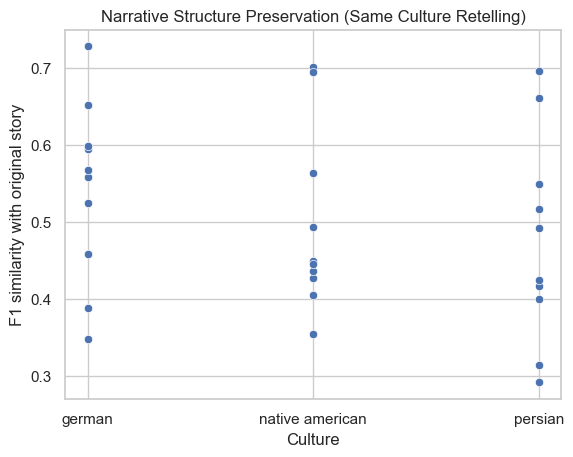

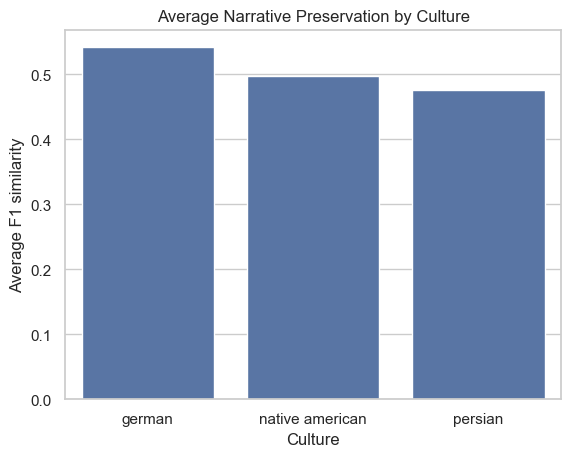

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("outputs/analysis_same_culture.csv")

sns.set(style="whitegrid")

# -----------------------------
# Plot 1: F1 per story
# -----------------------------

plt.figure()

sns.scatterplot(
    data=df,
    x="culture",
    y="f1"
)

plt.title("Narrative Structure Preservation (Same Culture Retelling)")
plt.ylabel("F1 similarity with original story")
plt.xlabel("Culture")

plt.savefig("outputs/plot_f1_per_story.png", dpi=300)

plt.show()

# -----------------------------
# Plot 2: Average F1 per culture
# -----------------------------

culture_avg = df.groupby("culture")["f1"].mean().reset_index()

plt.figure()

sns.barplot(
    data=culture_avg,
    x="culture",
    y="f1"
)

plt.title("Average Narrative Preservation by Culture")
plt.ylabel("Average F1 similarity")
plt.xlabel("Culture")

plt.savefig("outputs/plot_f1_by_culture.png", dpi=300)

plt.show()

### Same vs Cross

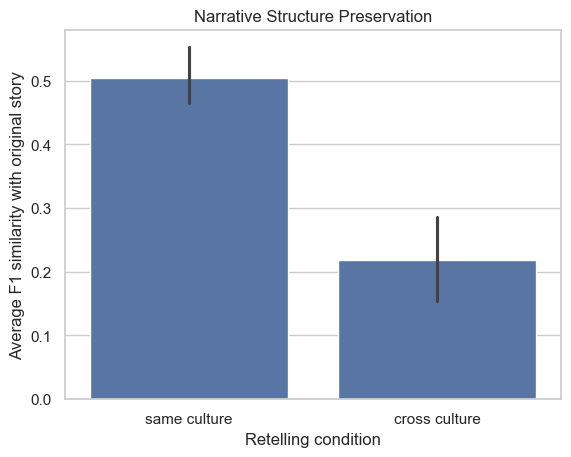

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

same = pd.read_csv("outputs/analysis_same_culture.csv")
cross = pd.read_csv("outputs/analysis_cross_culture.csv")

same["condition"] = "same culture"
cross["condition"] = "cross culture"

df = pd.concat([same, cross])

sns.set(style="whitegrid")

plt.figure()

sns.barplot(
    data=df,
    x="condition",
    y="f1"
)

plt.title("Narrative Structure Preservation")
plt.ylabel("Average F1 similarity with original story")
plt.xlabel("Retelling condition")

plt.savefig("outputs/plot_condition_comparison.png", dpi=300)

plt.show()

In [13]:
import pandas as pd

same = pd.read_csv("outputs/analysis_same_culture.csv")
cross = pd.read_csv("outputs/analysis_cross_culture.csv")

same["condition"] = "same_culture"
cross["condition"] = "cross_culture"

df = pd.concat([same, cross])

culture_summary = (
    df.groupby(["culture","condition"])["f1"]
    .mean()
    .reset_index()
)

print(culture_summary)

culture_summary.to_csv(
    "outputs/culture_condition_summary.csv",
    index=False
)

print("\nSaved summary to outputs/culture_condition_summary.csv")

           culture      condition        f1
0           german  cross_culture  0.301527
1           german   same_culture  0.541644
2  native american  cross_culture  0.087309
3  native american   same_culture  0.496815
4          persian  cross_culture  0.264671
5          persian   same_culture  0.476023

Saved summary to outputs/culture_condition_summary.csv


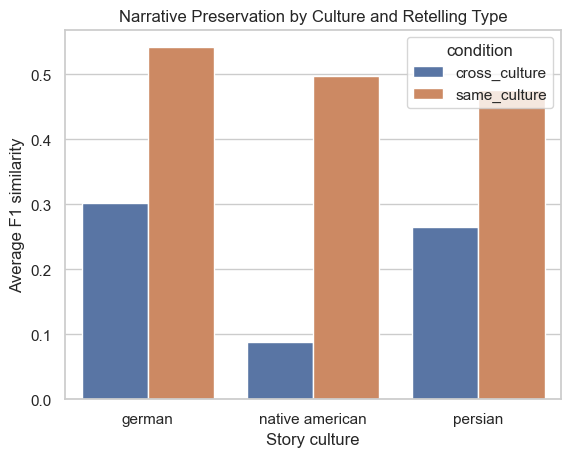

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure()

sns.barplot(
    data=culture_summary,
    x="culture",
    y="f1",
    hue="condition"
)

plt.title("Narrative Preservation by Culture and Retelling Type")
plt.ylabel("Average F1 similarity")
plt.xlabel("Story culture")

plt.savefig(
    "outputs/plot_culture_condition.png",
    dpi=300
)

plt.show()

In [15]:
pivot = culture_summary.pivot(
    index="culture",
    columns="condition",
    values="f1"
)

pivot["drop"] = pivot["same_culture"] - pivot["cross_culture"]

print(pivot)

condition        cross_culture  same_culture      drop
culture                                               
german                0.301527      0.541644  0.240117
native american       0.087309      0.496815  0.409506
persian               0.264671      0.476023  0.211353


#### extremes

In [16]:
import pandas as pd

same = pd.read_csv("outputs/analysis_same_culture.csv")
cross = pd.read_csv("outputs/analysis_cross_culture.csv")

print("Same-culture extremes:")
best_same = same.loc[same["f1"].idxmax()]
worst_same = same.loc[same["f1"].idxmin()]
print("\nHighest F1:")
print(best_same)
print("\nLowest F1:")
print(worst_same)

print("\nCross-culture extremes:")
best_cross = cross.loc[cross["f1"].idxmax()]
worst_cross = cross.loc[cross["f1"].idxmin()]
print("\nHighest F1:")
print(best_cross)
print("\nLowest F1:")
print(worst_cross)

Same-culture extremes:

Highest F1:
story_id                g07
culture              german
precision          0.747748
recall             0.709402
f1                  0.72807
events_original         117
events_llm              111
Name: 6, dtype: object

Lowest F1:
story_id                p10
culture             persian
precision          0.495495
recall             0.205993
f1                 0.291005
events_original         267
events_llm              111
Name: 29, dtype: object

Cross-culture extremes:

Highest F1:
story_id                g07
culture              german
precision          0.986486
recall             0.623932
f1                 0.764398
events_original         117
events_llm               74
Name: 6, dtype: object

Lowest F1:
story_id                       n01
culture            native american
precision                      0.0
recall                         0.0
f1                             0.0
events_original                 20
events_llm                      15

In [17]:
from pathlib import Path

def show_story_pair(story_id, condition="same"):
    
    human_path = Path(f"data/human") 
    llm_path = Path(f"data/llm/{'same_culture' if condition=='same' else 'cross_culture'}/{story_id}.txt")

    # find correct culture folder automatically
    import pandas as pd
    meta = pd.read_csv("data/metadata.csv")
    culture = meta[meta.story_id == story_id]["culture"].values[0]

    human_file = Path(f"data/human/{culture}/{story_id}.txt")

    print("\nORIGINAL STORY\n")
    print(human_file.read_text()[:2000])

    print("\n\nRETOLD STORY\n")
    print(llm_path.read_text()[:2000])

In [18]:
show_story_pair("g07", "same")
show_story_pair("n01", "cross")


ORIGINAL STORY

THE FISHERMAN AND HIS WIFE

There was once a fisherman who lived with his wife in a pigsty, close by the seaside. The fisherman used to go out all day long a-fishing; and one day, as he sat on the shore with his rod, looking at the sparkling waves and watching his line, all on a sudden his float was dragged away deep into the water: and in drawing it up he pulled out a great fish. But the fish said, â€کPray let me live! I am not a real fish; I am an enchanted prince: put me in the water again, and let me go!â€™ â€کOh, ho!â€™ said the man, â€کyou need not make so many words about the matter; I will have nothing to do with a fish that can talk: so swim away, sir, as soon as you please!â€™ Then he put him back into the water, and the fish darted straight down to the bottom, and left a long streak of blood behind him on the wave.

When the fisherman went home to his wife in the pigsty, he told her how he had caught a great fish, and how it had told him it was an enchanted 

### graph metrics comparison 

In [19]:
import pandas as pd

df = pd.read_csv("outputs/graph_metrics_comparison.csv")

summary = (
    df.groupby(["culture", "condition"])[
        [
            "compression_ratio_nodes",
            "compression_ratio_edges",
            "longest_path_ratio",
            "density_diff",
            "avg_degree_diff"
        ]
    ]
    .mean()
    .reset_index()
)

print(summary)
summary.to_csv("outputs/graph_metrics_summary.csv", index=False)

           culture      condition  compression_ratio_nodes  \
0           german  cross_culture                 0.876608   
1           german   same_culture                 1.114136   
2  native american  cross_culture                 0.615629   
3  native american   same_culture                 0.945711   
4          persian  cross_culture                 0.700781   
5          persian   same_culture                 0.902134   

   compression_ratio_edges  longest_path_ratio  density_diff  avg_degree_diff  
0                 0.876061            0.876061      0.002086        -0.004173  
1                 1.116543            1.116543     -0.001620         0.003240  
2                 0.609242            0.609242      0.011345        -0.022690  
3                 0.945111            0.945111      0.000937        -0.001874  
4                 0.700180            0.700180      0.004522        -0.009045  
5                 0.903753            0.903753     -0.000606         0.001212  


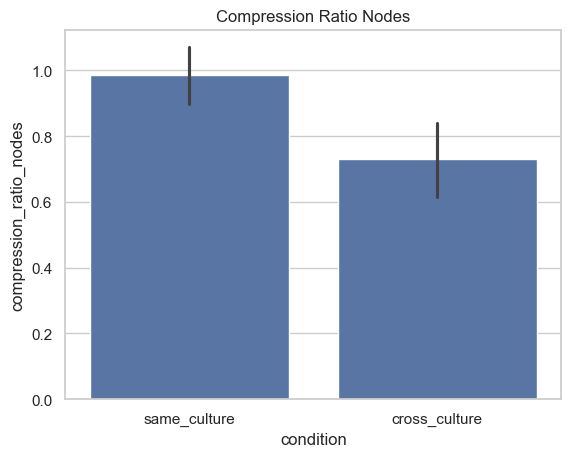

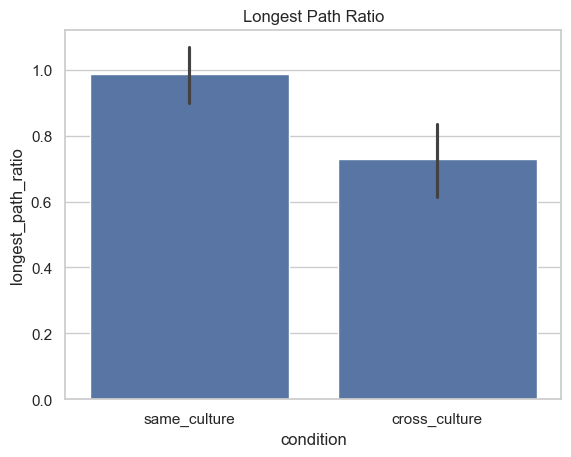

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("outputs/graph_metrics_comparison.csv")

sns.set(style="whitegrid")

metrics = [
    "compression_ratio_nodes",
    "longest_path_ratio"
]

for metric in metrics:
    plt.figure()
    sns.barplot(data=df, x="condition", y=metric)
    plt.title(metric.replace("_", " ").title())
    plt.savefig(f"outputs/{metric}_by_condition.png", dpi=300)
    plt.show()

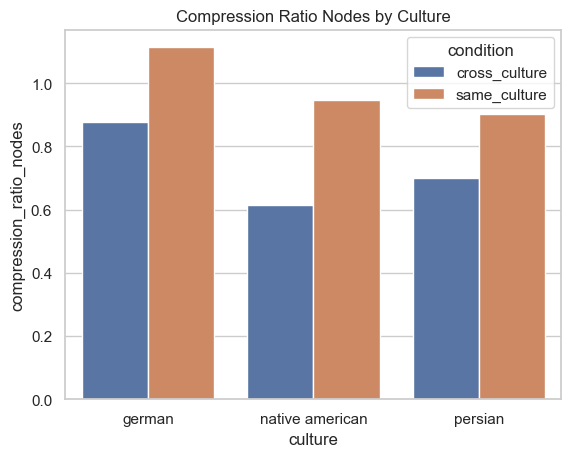

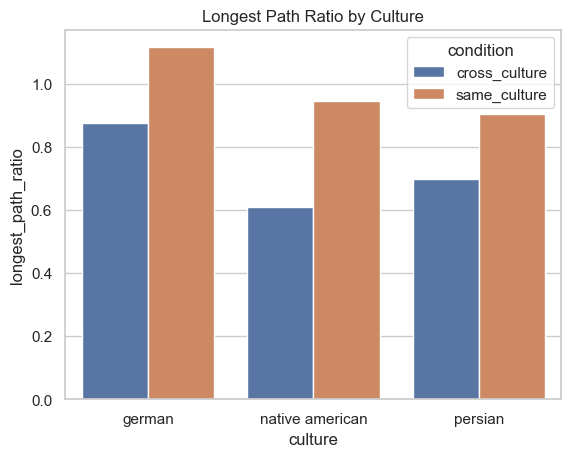

In [21]:
summary = (
    df.groupby(["culture", "condition"])[
        ["compression_ratio_nodes", "longest_path_ratio"]
    ]
    .mean()
    .reset_index()
)

for metric in ["compression_ratio_nodes", "longest_path_ratio"]:
    plt.figure()
    sns.barplot(data=summary, x="culture", y=metric, hue="condition")
    plt.title(metric.replace("_", " ").title() + " by Culture")
    plt.savefig(f"outputs/{metric}_by_culture_condition.png", dpi=300)
    plt.show()

#### checking the language

In [22]:
from pathlib import Path
from langdetect import detect

for file in Path("data/llm/cross_culture").glob("*.txt"):
    
    text = file.read_text()
    
    try:
        lang = detect(text)
    except:
        lang = "unknown"
    
    print(file.name, "->", lang)

g01.txt -> en
g02.txt -> en
g03.txt -> en
g04.txt -> en
g05.txt -> en
g06.txt -> en
g07.txt -> en
g08.txt -> en
g09.txt -> en
g10.txt -> en
n01.txt -> en
n02.txt -> en
n03.txt -> en
n04.txt -> en
n05.txt -> en
n06.txt -> en
n07.txt -> en
n08.txt -> en
n09.txt -> en
n10.txt -> en
p01.txt -> en
p02.txt -> en
p03.txt -> en
p04.txt -> en
p05.txt -> en
p06.txt -> en
p07.txt -> en
p08.txt -> en
p09.txt -> en
p10.txt -> en


In [23]:
pip install langdetect

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### More plots and metrics

In [24]:
from scipy.stats import ttest_ind

same = df[df["condition"]=="same_culture"]["compression_ratio_nodes"]
cross = df[df["condition"]=="cross_culture"]["compression_ratio_nodes"]

print(ttest_ind(same, cross))

TtestResult(statistic=np.float64(3.54256095637155), pvalue=np.float64(0.0007898927373256049), df=np.float64(58.0))


In [25]:
from scipy.stats import ttest_ind

same = df[df["condition"]=="same_culture"]["longest_path_ratio"]
cross = df[df["condition"]=="cross_culture"]["longest_path_ratio"]

print(ttest_ind(same, cross))

TtestResult(statistic=np.float64(3.5547798845464356), pvalue=np.float64(0.0007603962781455747), df=np.float64(58.0))


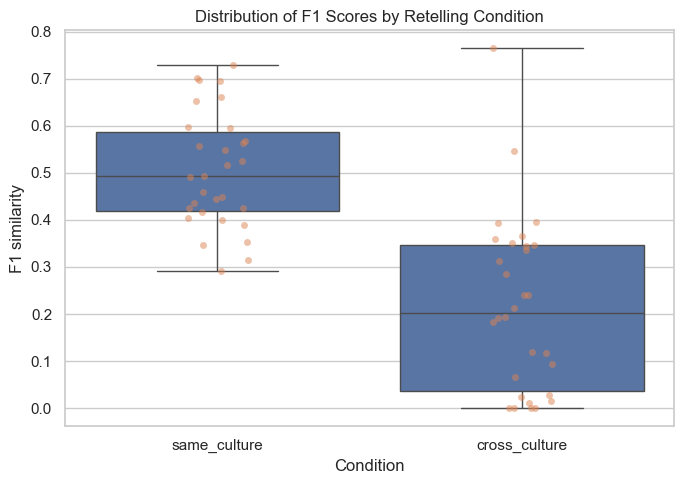

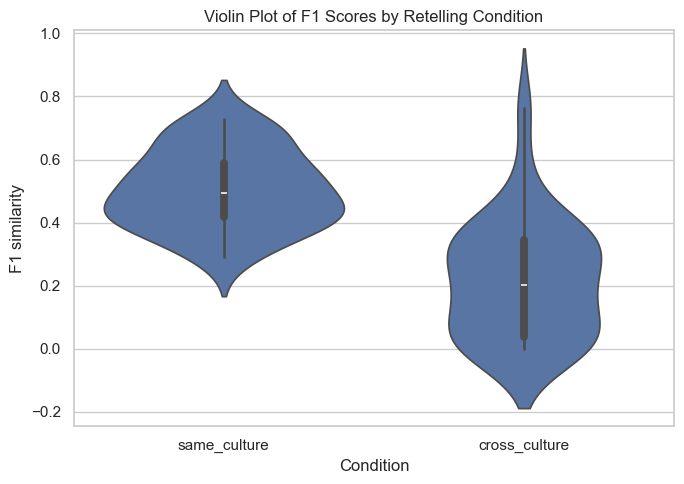

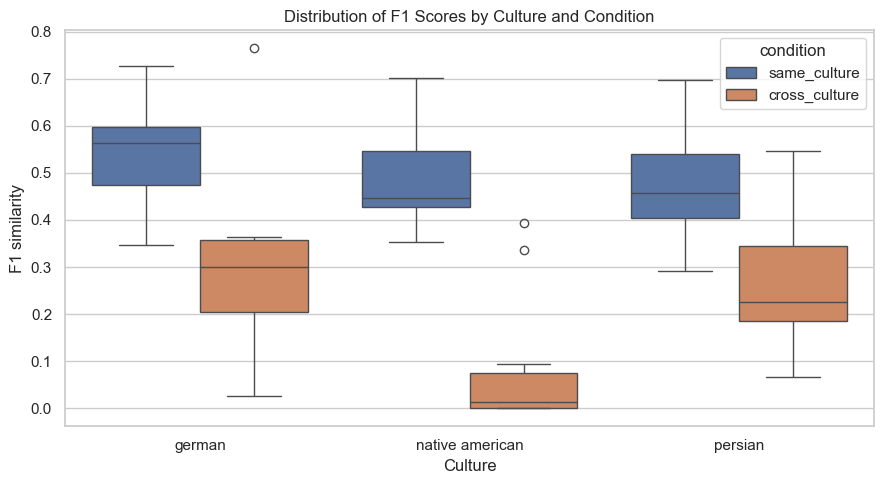

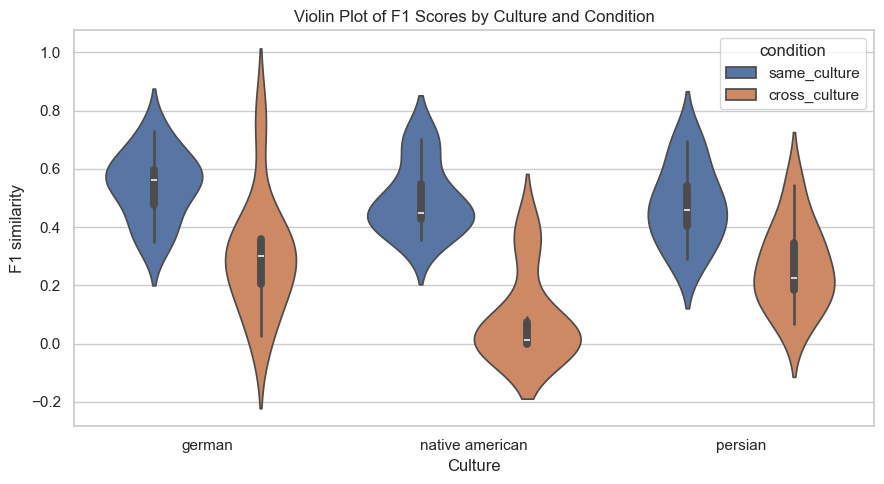

                               count      mean       std       min       25%  \
condition     culture                                                          
cross_culture german            10.0  0.301527  0.197112  0.027027  0.203478   
              native american   10.0  0.087309  0.149573  0.000000  0.000000   
              persian           10.0  0.264671  0.143164  0.066667  0.184879   
same_culture  german            10.0  0.541644  0.116653  0.347222  0.474766   
              native american   10.0  0.496815  0.119250  0.353982  0.428543   
              persian           10.0  0.476023  0.134482  0.291005  0.403960   

                                    50%       75%       max  
condition     culture                                        
cross_culture german           0.299107  0.358098  0.764398  
              native american  0.013141  0.075755  0.393701  
              persian          0.226572  0.345637  0.545455  
same_culture  german           0.562601  0.597468

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
same = pd.read_csv("outputs/analysis_same_culture.csv")
cross = pd.read_csv("outputs/analysis_cross_culture.csv")

same["condition"] = "same_culture"
cross["condition"] = "cross_culture"

df = pd.concat([same, cross], ignore_index=True)

sns.set(style="whitegrid")

# -----------------------------
# 1) Overall box plot
# -----------------------------
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="condition", y="f1")
sns.stripplot(data=df, x="condition", y="f1", dodge=False, alpha=0.5)
plt.title("Distribution of F1 Scores by Retelling Condition")
plt.xlabel("Condition")
plt.ylabel("F1 similarity")
plt.tight_layout()
plt.savefig("outputs/f1_boxplot_by_condition.png", dpi=300)
plt.show()

# -----------------------------
# 2) Overall violin plot
# -----------------------------
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="condition", y="f1", inner="box")
plt.title("Violin Plot of F1 Scores by Retelling Condition")
plt.xlabel("Condition")
plt.ylabel("F1 similarity")
plt.tight_layout()
plt.savefig("outputs/f1_violin_by_condition.png", dpi=300)
plt.show()

# -----------------------------
# 3) Per-culture box plot
# -----------------------------
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="culture", y="f1", hue="condition")
plt.title("Distribution of F1 Scores by Culture and Condition")
plt.xlabel("Culture")
plt.ylabel("F1 similarity")
plt.tight_layout()
plt.savefig("outputs/f1_boxplot_by_culture_condition.png", dpi=300)
plt.show()

# -----------------------------
# 4) Per-culture violin plot
# -----------------------------
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x="culture", y="f1", hue="condition", split=False, inner="box")
plt.title("Violin Plot of F1 Scores by Culture and Condition")
plt.xlabel("Culture")
plt.ylabel("F1 similarity")
plt.tight_layout()
plt.savefig("outputs/f1_violin_by_culture_condition.png", dpi=300)
plt.show()

# -----------------------------
# 5) Handy summary stats
# -----------------------------
summary = df.groupby(["condition", "culture"])["f1"].describe()
print(summary)